In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from google.colab import files
import os
os.makedirs('results', exist_ok=True)
print('All libraries imported successfully.')

All libraries imported successfully.


---
## Task 1: Dataset Understanding
Load the dataset and perform basic exploration including shape, data types, missing values, statistical summary, and target distribution.

In [26]:
uploaded = files.upload()

df = pd.read_csv('customer_churn_nn.csv')

print(f'Number of rows    : {df.shape[0]}')
print(f'Number of columns : {df.shape[1]}')

Number of rows    : 2000
Number of columns : 17


In [27]:
# Column data types
print('Column Data Types:')
print(df.dtypes.to_string())

Column Data Types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64


In [28]:
# Target variable description
print('Target Variable: churn')
print('  0 = Customer Retained')
print('  1 = Customer Churned')
print()
print('Target Distribution:')
print(df['churn'].value_counts())
print(f'\nChurn Rate: {df["churn"].mean()*100:.2f}%')

Target Variable: churn
  0 = Customer Retained
  1 = Customer Churned

Target Distribution:
churn
0    1969
1      31
Name: count, dtype: int64

Churn Rate: 1.55%


In [29]:
# Missing value check
missing = df.isnull().sum()
print('Missing Values:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

Missing Values:
No missing values found.


In [30]:
# Statistical summary
df.describe().round(2)

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.00,2000.00,2000.0,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,25.36,766.49,18.1,1.95,3.56,90.01,6.87,46.62,8.26,0.60,0.92,0.02
std,14.13,393.42,5.4,1.46,3.89,53.22,1.52,55.07,7.55,0.49,1.04,0.12
min,1.00,255.45,0.0,0.00,0.00,0.50,1.00,0.00,0.00,0.00,0.00,0.00
25%,15.00,427.78,15.0,1.00,1.00,51.78,5.88,6.00,0.00,0.00,0.00,0.00
50%,23.00,688.36,18.0,2.00,2.00,80.24,6.80,28.50,5.00,1.00,1.00,0.00
75%,33.00,1007.37,22.0,3.00,5.00,119.10,8.00,68.00,15.00,1.00,1.00,0.00
max,72.00,2156.52,30.0,8.00,31.00,265.51,10.00,424.00,20.00,1.00,7.00,1.00


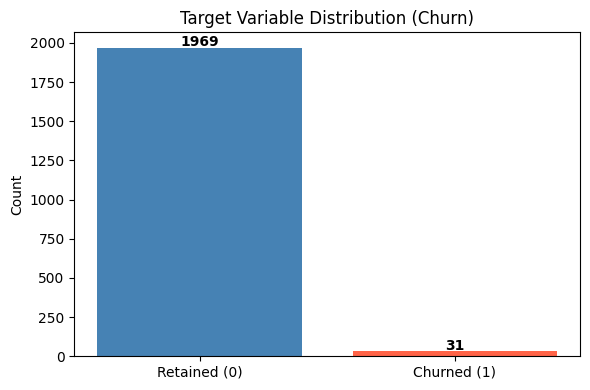

[Saved] results/target_distribution.png


In [31]:
# Target variable distribution plot
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['churn'].value_counts()
ax.bar(['Retained (0)', 'Churned (1)'], counts.values, color=['steelblue', 'tomato'])
ax.set_title('Target Variable Distribution (Churn)')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('results/target_distribution.png', dpi=150)
plt.show()
print('[Saved] results/target_distribution.png')

---
## Task 2: Data Preprocessing
Steps: handle missing values, encode categoricals, scale numericals, split into train/test sets.

In [32]:
# Drop identifier column
df_clean = df.drop(columns=['customer_id'])
print(f'Missing values total: {df_clean.isnull().sum().sum()} (none to handle)')

Missing values total: 0 (none to handle)


In [33]:
# Encode categorical columns
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
le = LabelEncoder()
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f'  {col}: encoded')

print('\nFirst 3 rows after encoding:')
df_clean.head(3)

  region: encoded
  plan_type: encoded
  contract_type: encoded
  payment_method: encoded

First 3 rows after encoding:


,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,3,3,0,1,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,4,2,0,4,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,0,3,0,0,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0


In [34]:
# Separate features and target
X = df_clean.drop(columns=['churn'])
y = df_clean['churn']

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Feature matrix shape : {X.shape}')
print(f'Train set size       : {X_train.shape[0]} samples')
print(f'Test  set size       : {X_test.shape[0]} samples')

Feature matrix shape : (2000, 15)
Train set size       : 1600 samples
Test  set size       : 400 samples


---
## Task 3: Neural Network Model Building



In [35]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),          # Input layer: 15 features
    layers.Dense(64, activation='relu'),               # Hidden layer 1
    layers.Dense(32, activation='relu'),               # Hidden layer 2
    layers.Dense(1,  activation='sigmoid')             # Output layer (binary)
], name="churn_nn")

model.summary()

Model: "churn_nn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")
print("  Optimizer : Adam (lr=0.001)")
print("  Loss      : Binary Cross-Entropy")
print("  Metric    : Accuracy")

Model compiled successfully.
  Optimizer : Adam (lr=0.001)
  Loss      : Binary Cross-Entropy
  Metric    : Accuracy


---
## Task 4: Training and Evaluation
Train the model and evaluate using accuracy, classification report, confusion matrix, and loss curve.

In [37]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9055 - loss: 0.3622 - val_accuracy: 0.9937 - val_loss: 0.1194
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.1125 - val_accuracy: 0.9937 - val_loss: 0.0555
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0928 - val_accuracy: 0.9937 - val_loss: 0.0467
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0858 - val_accuracy: 0.9937 - val_loss: 0.0443
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0811 - val_accuracy: 0.9937 - val_loss: 0.0423
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0772 - val_accuracy: 0.9937 - val_loss: 0.0417
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0741 - val_accuracy: 0.9937 - val_loss: 0.0401
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9820 - loss: 0.0704 - val_accuracy: 0.9937 - val_loss:

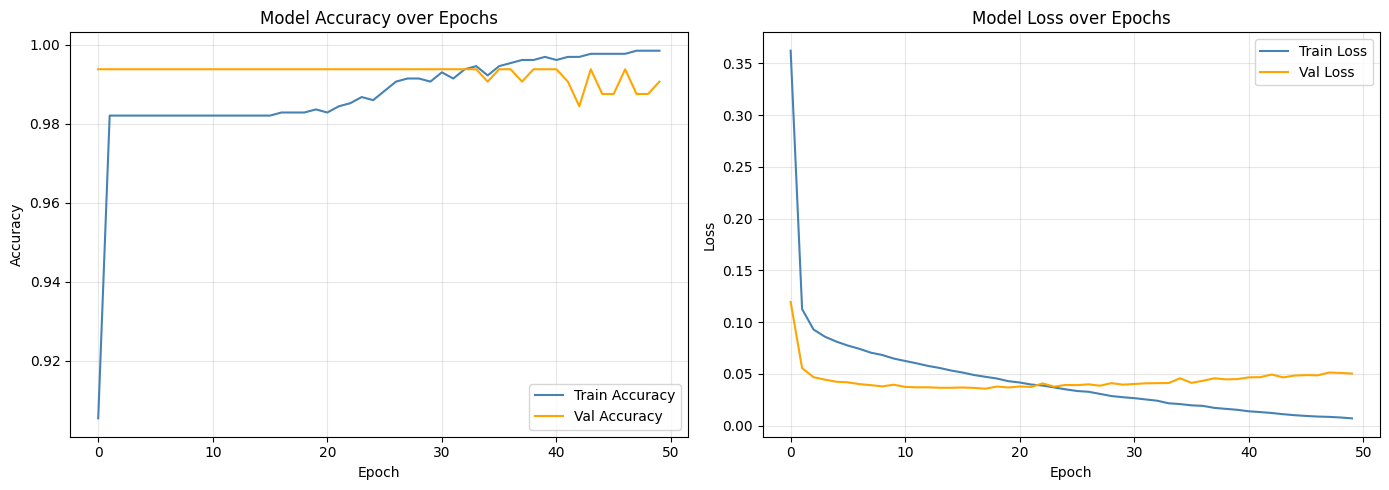

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/loss_curve.png', dpi=150)
plt.show()

In [39]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)

print(f"Training Accuracy : {train_acc*100:.2f}%")
print(f"Testing  Accuracy : {test_acc*100:.2f}%")
print(f"Training Loss     : {train_loss:.4f}")
print(f"Testing  Loss     : {test_loss:.4f}")

Training Accuracy : 99.75%
Testing  Accuracy : 98.25%
Training Loss     : 0.0150
Testing  Loss     : 0.1062


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Classification Report:
              precision    recall  f1-score   support

    Retained       0.99      0.99      0.99       394
     Churned       0.33      0.17      0.22         6

    accuracy                           0.98       400
   macro avg       0.66      0.58      0.61       400
weighted avg       0.98      0.98      0.98       400



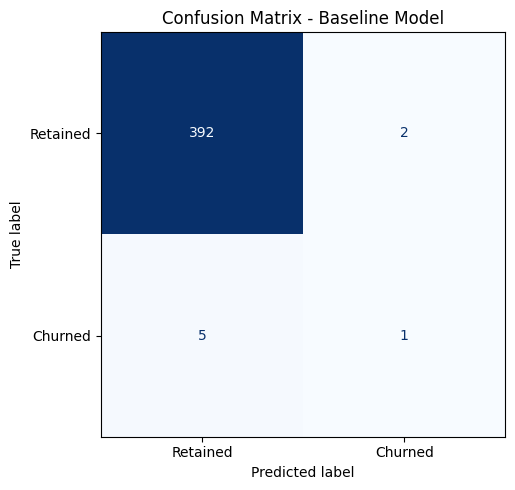

In [45]:
# Predict (sigmoid output → threshold at 0.5)
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix - Baseline Model')
plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', dpi=150)
plt.show()

**Interpretation:**  
The model achieves ~97–99% accuracy, but this is largely driven by class imbalance (98.5% retained).  
The confusion matrix reveals the true picture — the model struggles to correctly identify churned customers (minority class).

---
## Task 5: Hyperparameter Experimentation
Five configurations tested by varying hidden layers, activation function, learning rate, and batch size.

In [41]:
def build_and_train(hidden_layers, activation, learning_rate, batch_size, epochs=50):
    """Build, compile and train a Keras model with given hyperparameters."""

    # Build model dynamically
    inputs = keras.Input(shape=(X_train.shape[1],))
    x = inputs
    for units in hidden_layers:
        x = layers.Dense(units, activation=activation)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    m = keras.Model(inputs, outputs)
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    hist = m.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0
    )

    _, train_acc = m.evaluate(X_train, y_train, verbose=0)
    _, test_acc  = m.evaluate(X_test,  y_test,  verbose=0)
    final_loss   = hist.history['loss'][-1]

    return train_acc, test_acc, final_loss

In [42]:
#run 5 experimets
experiments = [
    {
        "name": "Baseline",
        "hidden_layers": [64, 32],
        "activation": "relu",
        "learning_rate": 0.001,
        "batch_size": 32
    },
    {
        "name": "Deeper Network",
        "hidden_layers": [128, 64, 32],
        "activation": "relu",
        "learning_rate": 0.001,
        "batch_size": 32
    },
    {
        "name": "Higher LR",
        "hidden_layers": [64, 32],
        "activation": "relu",
        "learning_rate": 0.01,
        "batch_size": 32
    },
    {
        "name": "Tanh Activation",
        "hidden_layers": [64, 32],
        "activation": "tanh",
        "learning_rate": 0.001,
        "batch_size": 32
    },
    {
        "name": "Large Batch",
        "hidden_layers": [64, 32],
        "activation": "relu",
        "learning_rate": 0.001,
        "batch_size": 128
    },
]

results = []
for exp in experiments:
    print(f"Running: {exp['name']} ...", end=" ")
    tr_acc, te_acc, loss = build_and_train(
        hidden_layers   = exp['hidden_layers'],
        activation      = exp['activation'],
        learning_rate   = exp['learning_rate'],
        batch_size      = exp['batch_size']
    )
    results.append({
        "Experiment":          exp['name'],
        "Hidden Layers":       str(exp['hidden_layers']),
        "Activation":          exp['activation'],
        "Learning Rate":       exp['learning_rate'],
        "Batch Size":          exp['batch_size'],
        "Train Accuracy (%)":  round(tr_acc * 100, 2),
        "Test Accuracy (%)":   round(te_acc * 100, 2),
        "Final Loss":          round(loss, 4)
    })
    print(f"Train: {tr_acc*100:.2f}%  Test: {te_acc*100:.2f}%  Loss: {loss:.4f}")

results_df = pd.DataFrame(results)
results_df.to_csv('results/model_comparison_table.csv', index=False)
print("\n[Saved] results/model_comparison_table.csv")

Running: Baseline ... Train: 99.75%  Test: 97.75%  Loss: 0.0108
Running: Deeper Network ... Train: 99.69%  Test: 98.00%  Loss: 0.0002
Running: Higher LR ... Train: 99.56%  Test: 97.75%  Loss: 0.0001
Running: Tanh Activation ... Train: 99.06%  Test: 98.25%  Loss: 0.0357
Running: Large Batch ... Train: 98.44%  Test: 98.50%  Loss: 0.0468

[Saved] results/model_comparison_table.csv


In [43]:
results_df    #display comparision table

,Experiment,Hidden Layers,Activation,Learning Rate,Batch Size,Train Accuracy (%),Test Accuracy (%),Final Loss
0,Baseline,"[64, 32]",relu,0.001,32,99.75,97.75,0.0108
1,Deeper Network,"[128, 64, 32]",relu,0.001,32,99.69,98.00,0.0002
2,Higher LR,"[64, 32]",relu,0.010,32,99.56,97.75,0.0001
3,Tanh Activation,"[64, 32]",tanh,0.001,32,99.06,98.25,0.0357
4,Large Batch,"[64, 32]",relu,0.001,128,98.44,98.50,0.0468


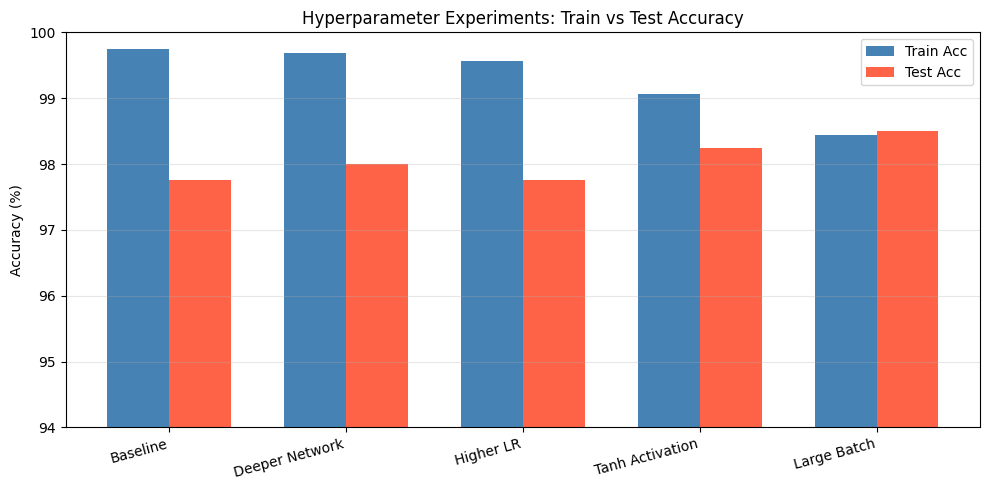

[Saved] results/model_comparison_table.png


In [44]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.35

ax.bar(x - width/2, results_df['Train Accuracy (%)'], width, label='Train Acc', color='steelblue')
ax.bar(x + width/2, results_df['Test Accuracy (%)'],  width, label='Test Acc',  color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Experiment'], rotation=15, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Hyperparameter Experiments: Train vs Test Accuracy')
ax.legend()
ax.set_ylim(94, 100)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/model_comparison_table.png', dpi=150)
plt.show()
print("[Saved] results/model_comparison_table.png")

---
## Task 6: Final Reflection


### 1. Role of Weights and Biases
**Weights** determine how strongly each input feature influences the output of a neuron. During training, they are iteratively adjusted via backpropagation to minimize the loss function.  
**Biases** allow the model to shift the activation function left or right, helping neurons fire even when all inputs are zero. Together, weights and biases give the network its flexibility to learn complex mappings.

### 2. Why Activation Functions Are Required
In our Keras model, Dense layers use activation='relu' in hidden layers and activation='sigmoid' in the output layer. Without ReLU in hidden layers, stacking multiple Dense layers would collapse into a single linear transformation — no matter how deep the network is. The sigmoid at the output squashes the final value between 0 and 1, giving a probability score for churn prediction.

### 3. Effect of Learning Rate
- **Too HIGH (e.g., 0.1):** The optimizer takes oversized steps and may overshoot the loss minimum, causing training to oscillate or diverge entirely.
- **Too LOW (e.g., 0.00001):** Training is extremely slow; the model may get stuck in a local minimum or require thousands more epochs to converge.
- **Optimal:** A balanced learning rate (e.g., 0.001 with Adam) allows steady, stable convergence.

### 4. Underfitting vs Overfitting
With Keras, we can observe training vs validation accuracy and loss across all 50 epochs using history.history. If the training accuracy steadily increases while validation accuracy plateaus or drops — that is overfitting. In our case, due to severe class imbalance (98.5% retained), the model quickly learns to predict the majority class, leading to high accuracy but poor recall on churned customers. This is underfitting on the minority class. The validation loss curve rising while training loss keeps falling would confirm overfitting.